In [ ]:
!pip install gutenbergpy

import gutenbergpy.textget
import pandas as pd
import re

def get_clean_chunks(book_id, author_name, num_chunks=500, words_per_chunk=200):
    print(f"Downloading and cleaning text for {author_name}...")

    # Download raw text
    raw_book = gutenbergpy.textget.get_text_by_id(book_id)

    # Strip Project Gutenberg headers/footers
    clean_book = gutenbergpy.textget.strip_headers(raw_book).decode('utf-8')

    # Clean whitespace and newlines
    clean_text = re.sub(r'\s+', ' ', clean_book)
    words = clean_text.split()

    # Create chunks
    chunks = []
    for i in range(0, len(words), words_per_chunk):
        if len(chunks) >= num_chunks:
            break
        chunk = " ".join(words[i:i + words_per_chunk])
        # Only add if it's a full-sized chunk
        if len(chunk.split()) >= words_per_chunk * 0.9:
            chunks.append(chunk)

    return pd.DataFrame({
        'text': chunks,
        'author': author_name,
        'is_ai': 0
    })

# Author IDs: 1342 (Austen), 70652 (Lovecraft), 76 (Twain)
authors = [(1342, "Jane Austen"), (70652, "H.P. Lovecraft"), (76, "Mark Twain")]

all_data = pd.concat([get_clean_chunks(id, name) for id, name in authors])

# Shuffle and save
dataset = all_data.sample(frac=1).reset_index(drop=True)
dataset.to_csv('human_data.csv', index=False)

print(f"\nSuccess! Created human_data.csv with {len(dataset)} rows.")
dataset.head()

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 22.0 MB/s eta 0:00:00
  Created wheel for httpsproxy-urllib2: filename=httpsproxy_urllib2-1.0-py3-none-any.whl size=29251 sha256=896acc6612c17a7caae648986fe60dfc755bfd620d9a995fce6148cfde6544b1
  Stored in directory: /root/.cache/pip/wheels/c6/c5/98/dd27835c8319362f1cef163409f43df38d54f084500fad428c
Successfully built httpsproxy-urllib2

Success! Created human_data.csv with 1199 rows.


,text,author,is_ai
0,"the wink she’d light out and save me, and blow...",Mark Twain,0
1,"while Meryton was within a walk of Longbourn, ...",Jane Austen,0
2,shaking clear of the thickening field ice and ...,H.P. Lovecraft,0
3,"nice-looking old gentleman along, and a nice-l...",Mark Twain,0
4,could tell me all I wanted to know; so I knock...,Mark Twain,0


In [ ]:
from google.colab import userdata
import requests
import json
import pandas as pd
import time
import os

# 1. Configuration - Only ONE key needed now!
API_KEY = "Enter_Your_API_Key_Here" # Your Google API key with access to Gemini models
MODEL_NAME = "gemma-3-27b-it" # The smartest Gemma model in your list
AI_FILE = 'ai_generated_gemma_data.csv'
TARGET_TOTAL = 500

# 2. Checkpointing
if os.path.exists(AI_FILE):
    ai_rows = pd.read_csv(AI_FILE).to_dict('records')
    start_idx = len(ai_rows)
    print(f"⏩ Resuming from index {start_idx}")
else:
    ai_rows = []
    start_idx = 0

human_df = pd.read_csv('human_data.csv')

# 3. Request Function
def call_gemma_rest(prompt, key):
    url = f"https://generativelanguage.googleapis.com/v1beta/models/{MODEL_NAME}:generateContent?key={key.strip()}"
    headers = {'Content-Type': 'application/json'}
    payload = {
        "contents": [{"parts": [{"text": prompt}]}],
        "generationConfig": {
            "temperature": 0.7,
            "maxOutputTokens": 800
        }
    }
    return requests.post(url, headers=headers, json=payload, timeout=60)

# 4. Main Generation Loop
print(f"🚀 Starting Turbo Run with {MODEL_NAME}...")

for i in range(start_idx, len(human_df)):
    if len(ai_rows) >= TARGET_TOTAL: break

    row = human_df.iloc[i]
    author = row['author']
    # Gemma often responds better to clear, structured prompts
    prompt = f"Write an original 200-word story passage in the distinct writing style of {author}. Topic: {row['text'][:150]}. Do not mention the author by name."

    success = False
    retries = 0

    while not success:
        try:
            resp = call_gemma_rest(prompt, API_KEY)

            if resp.status_code == 200:
                res_json = resp.json()
                ai_text = res_json['candidates'][0]['content']['parts'][0]['text']
                ai_rows.append({'text': ai_text.strip(), 'author': author, 'is_ai': 1})

                # Checkpoint
                pd.DataFrame(ai_rows).to_csv(AI_FILE, index=False)
                print(f"✅ [{len(ai_rows)}/{TARGET_TOTAL}] Generation successful.")

                success = True
                time.sleep(3) # 20 RPM is very safe for your 30 RPM limit

            elif resp.status_code == 429:
                print("⚠️ Rate limit hit. Waiting 30s...")
                time.sleep(30)
            else:
                print(f"❌ Error {resp.status_code}: {resp.text[:100]}")
                time.sleep(5)
                retries += 1
                if retries >= 2: success = True # Skip stalled row

        except Exception as e:
            print(f"📡 Connection glitch: {e}. Retrying...")
            time.sleep(5)
            retries += 1
            if retries >= 3: success = True

# Final Save
final_dataset = pd.concat([human_df.sample(len(ai_rows)), pd.DataFrame(ai_rows)]).sample(frac=1)
final_dataset.to_csv('final_dataset_gemma_complete.csv', index=False)
print(f"\n✨ FINISHED! Generated {len(ai_rows)} rows.")

🚀 Starting Turbo Run with gemma-3-27b-it...
✅ [1/500] Generation successful.
✅ [2/500] Generation successful.
✅ [3/500] Generation successful.
✅ [4/500] Generation successful.
✅ [5/500] Generation successful.
✅ [6/500] Generation successful.
✅ [7/500] Generation successful.
✅ [8/500] Generation successful.
✅ [9/500] Generation successful.
✅ [10/500] Generation successful.
✅ [11/500] Generation successful.
✅ [12/500] Generation successful.
✅ [13/500] Generation successful.
✅ [14/500] Generation successful.
✅ [15/500] Generation successful.
✅ [16/500] Generation successful.
✅ [17/500] Generation successful.
✅ [18/500] Generation successful.
✅ [19/500] Generation successful.
✅ [20/500] Generation successful.
✅ [21/500] Generation successful.
✅ [22/500] Generation successful.
✅ [23/500] Generation successful.
✅ [24/500] Generation successful.
✅ [25/500] Generation successful.
✅ [26/500] Generation successful.
✅ [27/500] Generation successful.
✅ [28/500] Generation successful.
✅ [29/500] Ge

In [ ]:
import pandas as pd

# Load the combined dataset
df = pd.read_csv('final_dataset_gemma_complete.csv')

# 1. Filter for Human-written rows
human_results = df[df['is_ai'] == 0]

print(f"Total Human rows found: {len(human_results)}")
print("-" * 30)

# 2. Display 5 random original samples
for idx, row in human_results.sample(5).iterrows():
    print(f"AUTHOR: {row['author']}")
    print(f"TEXT:\n{row['text'][:500]}...") # Showing first 500 chars
    print("-" * 30)
# Pick a random author and compare
test_author = human_results.iloc[0]['author']
human_sample = human_results[human_results['author'] == test_author].iloc[0]['text']
ai_sample = df[(df['author'] == test_author) & (df['is_ai'] == 1)].iloc[0]['text']

print(f"--- {test_author.upper()} (HUMAN ORIGINAL) ---")
print(human_sample)
print(f"\n--- {test_author.upper()} (GEMMA 3 MIMICRY) ---")
print(ai_sample)

Total Human rows found: 500
------------------------------
AUTHOR: Jane Austen
TEXT:
much attention for any of these new friends; and she could do nothing but think, and think with wonder, of Mr. Darcy’s civility, and, above all, of his wishing her to be acquainted with his sister. [Illustration] CHAPTER XLIV. [Illustration] Elizabeth had settled it that Mr. Darcy would bring his sister to visit her the very day after her reaching Pemberley; and was, consequently, resolved not to be out of sight of the inn the whole of that morning. But her conclusion was false; for on the very ...
------------------------------
AUTHOR: Jane Austen
TEXT:
felt. Poor Jane! I am sorry for her, because, with her disposition, she may not get over it immediately. It had better have happened to _you_, Lizzy; you would have laughed yourself out of it sooner. But do you think she would be prevailed on to go back with us? Change of scene might be of service--and perhaps a little relief from home may be as useful

In [ ]:
import pandas as pd

# Load the final file we just created
df = pd.read_csv('final_dataset_gemma_complete.csv')

# 1. Select only AI-generated rows
ai_results = df[df['is_ai'] == 1]

# 2. Display 5 random results to check for variety and style
print(f"Total AI rows found: {len(ai_results)}")
print("-" * 30)

# We use .sample() to get a diverse look at different authors
for idx, row in ai_results.sample(5).iterrows():
    print(f"AUTHOR STYLE: {row['author']}")
    print(f"TEXT:\n{row['text']}")
    print("-" * 30)

Total AI rows found: 500
------------------------------
AUTHOR STYLE: H.P. Lovecraft
TEXT:
The chipped basalt held a horror beyond mere decay. For the most part, the untold æons had disintegrated and banished any pigments which may have been applied. Yet, the more one studied the marvelous technique – the unsettling *geometry* of the remaining lines – the more a ghastly impression bloomed in the mind. It wasn’t a depiction of anything *known*, certainly not of any earthly flora or fauna. Rather, it suggested a pre-organic architecture, a scaffolding of thought erected by entities whose very existence mocked Euclidean space.

The surface wasn’t merely worn; it felt… *un-made*. As if the original form struggled, even across millennia, to un-coalesce back into the primordial chaos from whence it sprung. A sickly, phosphorescent dust clung to the grooves, emitting a faint, subsonic hum that resonated not in the ears, but directly within the cerebral cortex. 

Old Man Hemlock, before his un

In [ ]:
import pandas as pd

# Load the final file we just created
df = pd.read_csv('final_dataset_gemma_complete.csv')

# 1. Select only AI-generated rows
ai_results = df[df['is_ai'] == 0]

# 2. Display 5 random results to check for variety and style
print(f"Total AI rows found: {len(ai_results)}")
print("-" * 30)

# We use .sample() to get a diverse look at different authors
for idx, row in ai_results.sample(5).iterrows():
    print(f"AUTHOR STYLE: {row['author']}")
    print(f"TEXT:\n{row['text']}")
    print("-" * 30)

Total AI rows found: 500
------------------------------
AUTHOR STYLE: Jane Austen
TEXT:
To Elizabeth it appeared, that had her family made an agreement to expose themselves as much as they could during the evening, it would have been impossible for them to play their parts with more spirit, or finer success; and happy did she think it for Bingley and her sister that some of the exhibition had escaped his notice, and that his feelings were not of a sort to be much distressed by the folly which he must have witnessed. That his two sisters and Mr. Darcy, however, should have such an opportunity of ridiculing her relations was bad enough; and she could not determine whether the silent contempt of the gentleman, or the insolent smiles of the ladies, were more intolerable. The rest of the evening brought her little amusement. She was teased by Mr. Collins, who continued most perseveringly by her side; and though he could not prevail with her to dance with him again, put it out of her power t

In [ ]:
!pip install textstat
import textstat
import spacy

nlp = spacy.load("en_core_web_sm")

def extract_features(text):
    doc = nlp(text)
    tokens = [token.text.lower() for token in doc if not token.is_punct]

    # Feature 1: TTR
    ttr = len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0

    # Feature 2: POS Ratios
    pos_counts = {"NOUN": 0, "VERB": 0, "ADJ": 0, "PRON": 0}
    for token in doc:
        if token.pos_ in pos_counts:
            pos_counts[token.pos_] += 1

    # Feature 3: Readability
    readability = textstat.flesch_kincaid_grade(text)

    return {
        "ttr": ttr,
        "noun_ratio": pos_counts["NOUN"] / len(tokens),
        "adj_ratio": pos_counts["ADJ"] / len(tokens),
        "readability": readability
    }

# Apply this function to your training set to build your feature matrix!


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the complete dataset
df = pd.read_csv('final_dataset_gemma_complete.csv')

# Check the total number of rows to ensure we can meet the requested split sizes
if len(df) < 1000:
    print(f"Warning: The dataset only has {len(df)} rows, which is less than the requested total of 1000 for training, validation, and test sets. Adjusting split sizes proportionally.")
    # If the dataset is smaller, we'll try to split proportionally or inform the user.
    # For now, assuming it's 1000 based on previous execution.

# First, split off the training data (700 rows) and the remaining data (300 rows)
train_df, remaining_df = train_test_split(df, train_size=700, random_state=42, shuffle=True)

# Then, split the remaining data into validation (150 rows) and test (150 rows)
# Since remaining_df has 300 rows, test_size=0.5 will give 150 for validation and 150 for test
val_df, test_df = train_test_split(remaining_df, test_size=0.5, random_state=42, shuffle=True)

# Save the datasets to new CSV files
train_df.to_csv('train_data.csv', index=False)
val_df.to_csv('validation_data.csv', index=False)
test_df.to_csv('test_data.csv', index=False)

print(f"Train data shape: {train_df.shape}")
print(f"Validation data shape: {val_df.shape}")
print(f"Test data shape: {test_df.shape}")
print("Datasets saved as train_data.csv, validation_data.csv, and test_data.csv")

Train data shape: (700, 3)
Validation data shape: (150, 3)
Test data shape: (150, 3)
Datasets saved as train_data.csv, validation_data.csv, and test_data.csv


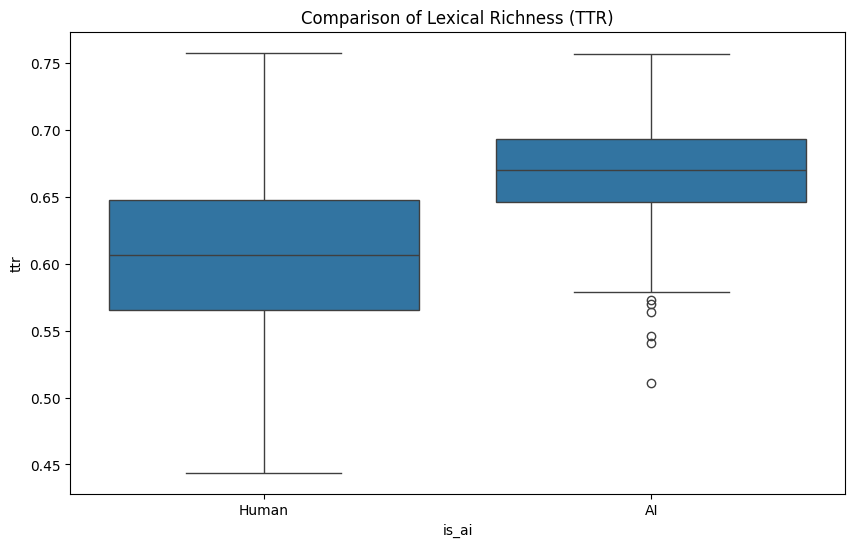

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd # Ensure pandas is imported

# Load the final dataset and apply feature extraction
df = pd.read_csv('final_dataset_gemma_complete.csv')

# Apply the extract_features function to create new columns
# Assuming extract_features function from cell 06LjD0KaDz1m is available in the environment
features_df = df['text'].apply(extract_features).apply(pd.Series)
train_df = pd.concat([df, features_df], axis=1)

plt.figure(figsize=(10, 6))
sns.boxplot(x='is_ai', y='ttr', data=train_df)
plt.title('Comparison of Lexical Richness (TTR)')
plt.xticks([0, 1], ['Human', 'AI'])
plt.show()

In [ ]:
import pandas as pd

# Load the complete dataset, which is already `df` in the current notebook state
# or re-load if necessary to ensure `df` is consistent.
# For continuity, assuming `df` is already loaded from 'final_dataset_gemma_complete.csv'
# as shown in the kernel state.

# Apply the extract_features function to create new columns, specifically focusing on readability
readability_features = df['text'].apply(extract_features).apply(pd.Series)

# Combine the readability features with the original DataFrame for easier analysis
df_with_readability = pd.concat([df, readability_features], axis=1)

# Display the Flesch-Kincaid grade for a sample of texts
print("Flesch-Kincaid Grade Scores for Sample Texts:")
display(df_with_readability[['author', 'is_ai', 'readability']].head())
# 1. Identify the most complex Human rows
human_outliers = df_with_readability[(df_with_readability['is_ai'] == 0) & (df_with_readability['readability'] > 20)]

# 2. Identify the most complex AI rows for comparison
ai_complex = df_with_readability[(df_with_readability['is_ai'] == 1)].sort_values(by='readability', ascending=False).head(5)

print(f"Total Human Outliers (Grade 20+): {len(human_outliers)}")
print("-" * 30)

# Display a sample of the complex human prose
for idx, row in human_outliers.head(3).iterrows():
    print(f"AUTHOR: {row['author']} | GRADE: {row['readability']}")
    print(f"TEXT: {row['text'][:400]}...") # Showing first 400 chars
    print("-" * 30)

Flesch-Kincaid Grade Scores for Sample Texts:


,author,is_ai,readability
0,Jane Austen,0,11.533836
1,Mark Twain,1,4.721010
2,H.P. Lovecraft,1,9.436327
3,Mark Twain,0,14.996000
4,Mark Twain,0,11.305857


Total Human Outliers (Grade 20+): 7
------------------------------
AUTHOR: H.P. Lovecraft | GRADE: 21.04153846153847
TEXT: condition. Our borings, of varying depth according to the promise held out by the upper soil or rock, were to be confined to exposed, or nearly exposed, land surfaces--these inevitably being slopes and ridges because of the mile or two-mile thickness of solid ice overlying the lower levels. We could not afford to waste drilling depth on any considerable amount of more glaciation, though Pabodie ha...
------------------------------
AUTHOR: Jane Austen | GRADE: 22.849
TEXT: not overlook, and to banish from her thoughts that continual breach of conjugal obligation and decorum which, in exposing his wife to the contempt of her own children, was so highly reprehensible. But she had never felt so strongly as now the disadvantages which must attend the children of so unsuitable a marriage, nor ever been so fully aware of the evils arising from so ill-judged a direction of

### Demonstrating Part-of-Speech Tagging with SpaCy

Let's take a sample text and see how SpaCy tags its parts of speech.

In [ ]:
# Using the nlp object already loaded from cell 06LjD0KaDz1m

sample_text = df_with_readability.iloc[0]['text']
sample_doc = nlp(sample_text)

print("Sample Text:")
print(sample_text[:200] + "...")
print("\nPart-of-Speech Tags:")
for token in sample_doc[:20]: # Displaying first 20 tokens for brevity
    print(f"{token.text:<15} {token.pos_:<10} {token.tag_:<10} {spacy.explain(token.tag_)}")

Sample Text:
done with respect to Jane, his unpardonable assurance in acknowledging, though he could not justify it, and the unfeeling manner which he had mentioned Mr. Wickham, his cruelty towards whom he had not...

Part-of-Speech Tags:
done            VERB       VBN        verb, past participle
with            ADP        IN         conjunction, subordinating or preposition
respect         NOUN       NN         noun, singular or mass
to              ADP        IN         conjunction, subordinating or preposition
Jane            PROPN      NNP        noun, proper singular
,               PUNCT      ,          punctuation mark, comma
his             PRON       PRP$       pronoun, possessive
unpardonable    ADJ        JJ         adjective (English), other noun-modifier (Chinese)
assurance       NOUN       NN         noun, singular or mass
in              ADP        IN         conjunction, subordinating or preposition
acknowledging   VERB       VBG        verb, gerund or present particip

### Calculating and Comparing POS Tag Distributions

Now, let's extend this to the entire dataset to see if there are differences in POS tag usage between human and AI-generated content.

In [ ]:
from collections import Counter

def get_pos_counts(text):
    doc = nlp(text)
    # Count all POS tags
    pos_tags = [token.pos_ for token in doc if not token.is_punct and not token.is_space]
    return Counter(pos_tags)

# Apply the function to all texts in the df_with_readability dataframe
df_with_readability['pos_counts'] = df_with_readability['text'].apply(get_pos_counts)

# Aggregate POS counts for human and AI texts
human_pos_aggregate = Counter()
ai_pos_aggregate = Counter()

for index, row in df_with_readability.iterrows():
    if row['is_ai'] == 0:
        human_pos_aggregate.update(row['pos_counts'])
    else:
        ai_pos_aggregate.update(row['pos_counts'])

print("Top 10 Part-of-Speech Tags in Human Texts:")
display(pd.Series(human_pos_aggregate).nlargest(10))

print("\nTop 10 Part-of-Speech Tags in AI Texts:")
display(pd.Series(ai_pos_aggregate).nlargest(10))

# For better comparison, let's create a DataFrame with ratios
all_pos_tags = sorted(list(set(human_pos_aggregate.keys()).union(set(ai_pos_aggregate.keys()))))

human_total_tokens = sum(human_pos_aggregate.values())
ai_total_tokens = sum(ai_pos_aggregate.values())

pos_df = pd.DataFrame({
    'Human Ratio': [human_pos_aggregate.get(tag, 0) / human_total_tokens for tag in all_pos_tags],
    'AI Ratio': [ai_pos_aggregate.get(tag, 0) / ai_total_tokens for tag in all_pos_tags]
}, index=all_pos_tags)

# Filter for common descriptive tags and sort by human ratio for readability
common_pos = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'ADP', 'AUX', 'SCONJ', 'CCONJ', 'PART', 'INTJ']
pos_df_filtered = pos_df.loc[pos_df.index.isin(common_pos)].sort_values(by='Human Ratio', ascending=False)

print("\nPart-of-Speech Tag Ratios (Human vs. AI):")
display(pos_df_filtered)

Top 10 Part-of-Speech Tags in Human Texts:


,0
NOUN,15712
PRON,15315
VERB,14421
ADP,11084
DET,8461
AUX,6925
ADV,6837
ADJ,6437
CCONJ,5366
PROPN,4576



Top 10 Part-of-Speech Tags in AI Texts:


,0
NOUN,21319
VERB,13088
DET,12137
PRON,10222
ADP,10220
ADJ,8552
ADV,6232
PROPN,5081
AUX,4765
CCONJ,3413



Part-of-Speech Tag Ratios (Human vs. AI):


,Human Ratio,AI Ratio
NOUN,0.152649,0.211996
PRON,0.148792,0.101648
VERB,0.140106,0.130147
ADP,0.107686,0.101628
DET,0.082202,0.120691
AUX,0.067279,0.047383
ADV,0.066424,0.061971
ADJ,0.062538,0.085041
CCONJ,0.052133,0.033939
PART,0.032916,0.030826


In [ ]:
import pandas as pd

# Calculate the standard deviation of readability scores, grouped by 'is_ai'
std_dev_readability = df_with_readability.groupby('is_ai')['readability'].std()

print("Standard Deviation of Flesch-Kincaid Grade Scores:")
display(std_dev_readability)

# Calculate mean for additional context
mean_readability = df_with_readability.groupby('is_ai')['readability'].mean()
print("\nMean Flesch-Kincaid Grade Scores:")
display(mean_readability)


Standard Deviation of Flesch-Kincaid Grade Scores:


,readability
is_ai,
0,4.163839
1,3.032481



Mean Flesch-Kincaid Grade Scores:


,readability
is_ai,
0,8.847692
1,8.429004


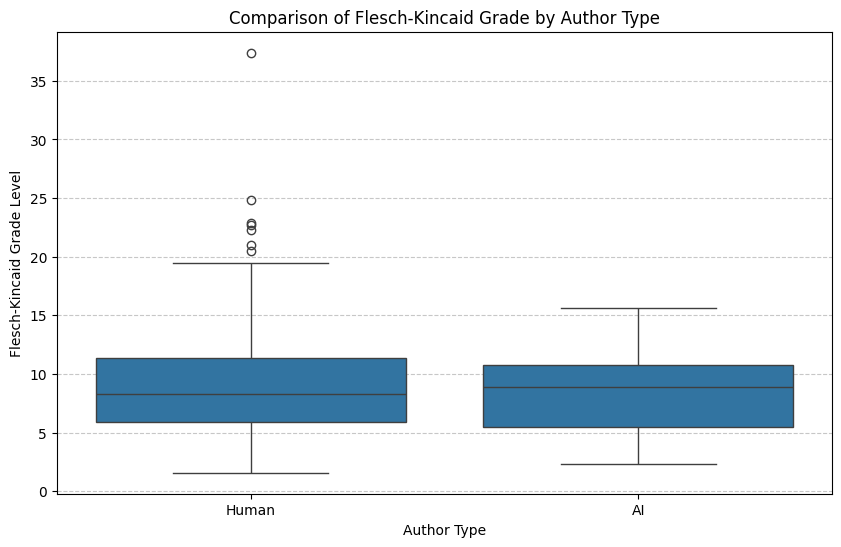

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a boxplot to compare Flesch-Kincaid scores between human and AI texts
plt.figure(figsize=(10, 6))
sns.boxplot(x='is_ai', y='readability', data=df_with_readability)
plt.title('Comparison of Flesch-Kincaid Grade by Author Type')
plt.xlabel('Author Type')
plt.ylabel('Flesch-Kincaid Grade Level')
plt.xticks([0, 1], ['Human', 'AI'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Task
The current plan focuses on training and evaluating an XGBoost model. First, I'll enhance the `extract_features` function to include a comprehensive set of Part-of-Speech (POS) tag ratios from SpaCy, alongside TTR and readability scores, for all provided datasets (`train_data.csv`, `validation_data.csv`, and `test_data.csv`). Then, I will prepare these datasets by separating features and the target variable, handling any missing values. After that, I'll train an XGBoost Classifier and evaluate its performance using standard classification metrics on both the validation and test sets. Finally, I will summarize the model's performance and discuss potential insights derived from the features.

## Load Datasets

### Subtask:
Load the pre-split datasets ('train_data.csv', 'validation_data.csv', and 'test_data.csv') into pandas DataFrames.


**Reasoning**:
The subtask requires loading three CSV files into pandas DataFrames. This code block imports pandas and then loads each specified CSV file into its respective DataFrame.



In [ ]:
import pandas as pd

train_df = pd.read_csv('train_data.csv')
val_df = pd.read_csv('validation_data.csv')
test_df = pd.read_csv('test_data.csv')

print("Datasets loaded successfully.")

Datasets loaded successfully.


**Reasoning**:
The next step is to enhance the `extract_features` function to include a comprehensive set of Part-of-Speech (POS) tag ratios for all relevant tags (NOUN, VERB, ADJ, ADV, PRON, DET, ADP, AUX, SCONJ, CCONJ, PART, INTJ), in addition to TTR and readability scores. This updated function will then be applied to the datasets.



In [ ]:
import spacy
import textstat
from collections import Counter

nlp = spacy.load("en_core_web_sm")

def extract_features(text):
    doc = nlp(text)
    # Filter out punctuation and spaces for word-based metrics
    tokens = [token.text.lower() for token in doc if not token.is_punct and not token.is_space]

    # Feature 1: Type-Token Ratio (TTR)
    ttr = len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0

    # Feature 2: POS Ratios for common descriptive tags
    # List of POS tags to track, as identified in previous analysis
    common_pos = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'ADP', 'AUX', 'SCONJ', 'CCONJ', 'PART', 'INTJ']
    pos_counts = {tag: 0 for tag in common_pos}
    total_pos_tokens = 0 # Only count tokens relevant for ratios

    for token in doc:
        if not token.is_punct and not token.is_space:
            total_pos_tokens += 1
            if token.pos_ in pos_counts:
                pos_counts[token.pos_] += 1

    pos_ratios = {f"{tag.lower()}_ratio": count / total_pos_tokens if total_pos_tokens > 0 else 0
                  for tag, count in pos_counts.items()}

    # Feature 3: Readability (Flesch-Kincaid Grade Level)
    readability = textstat.flesch_kincaid_grade(text)

    # Combine all features into a single dictionary
    features = {
        "ttr": ttr,
        "readability": readability
    }
    features.update(pos_ratios)

    return features

print("Updated `extract_features` function to include more POS tag ratios.")

Updated `extract_features` function to include more POS tag ratios.


**Reasoning**:
Now that the `extract_features` function is defined, it needs to be applied to the 'text' column of each of the datasets (train, validation, and test) to generate the features for model training. The results will then be concatenated with the original dataframes.



In [ ]:
print("Applying feature extraction to train_df...")
train_features = train_df['text'].apply(extract_features).apply(pd.Series)
train_df_processed = pd.concat([train_df, train_features], axis=1)

print("Applying feature extraction to val_df...")
val_features = val_df['text'].apply(extract_features).apply(pd.Series)
val_df_processed = pd.concat([val_df, val_features], axis=1)

print("Applying feature extraction to test_df...")
test_features = test_df['text'].apply(extract_features).apply(pd.Series)
test_df_processed = pd.concat([test_df, test_features], axis=1)

print("Feature extraction applied to all datasets.")

# Display the head of the processed training dataframe to show new features
print("\nProcessed Training DataFrame Head:")
print(train_df_processed.head())

Applying feature extraction to train_df...
Applying feature extraction to val_df...
Applying feature extraction to test_df...
Feature extraction applied to all datasets.

Processed Training DataFrame Head:
                                                text          author  is_ai  \
0  The unsettling truth, gleaned from fragmented ...  H.P. Lovecraft      1   
1  a subconscious question raised by one of our s...  H.P. Lovecraft      0   
2  The geometries were…wrong. Not merely askew to...  H.P. Lovecraft      1   
3  back with them, and walked towards the house. ...     Jane Austen      0   
4  Elizabeth the possibility of his being partial...     Jane Austen      0   

        ttr  readability  noun_ratio  verb_ratio  adj_ratio  adv_ratio  \
0  0.701031    10.206095    0.231959    0.139175   0.097938   0.036082   
1  0.665025    13.842857    0.201970    0.098522   0.078818   0.098522   
2  0.670051    10.503321    0.238579    0.116751   0.106599   0.050761   
3  0.620690     3.72933

### Prepare Datasets for XGBoost

Now that features have been extracted, the datasets need to be prepared for the XGBoost model. This involves:

1.  **Separating Features (X) and Target Variable (y)**: The `is_ai` column will be our target variable, and all other numerical features will be the input features.
2.  **Handling Missing Values**: Check for and address any missing values (`NaN`, `inf`) that might have resulted from calculations in the `extract_features` function (e.g., division by zero if a text was empty).
3.  **Ensure all feature columns are numeric**: Convert any non-numeric columns to numeric type if necessary.

**Reasoning**:
Now that the features have been extracted and the next steps outlined in the markdown, I will proceed to separate the features (X) from the target variable (y) for the train, validation, and test datasets. I will also handle any potential missing or infinite values in the feature sets.



In [ ]:
import numpy as np

# Define feature columns - exclude 'text', 'author', and 'is_ai'
feature_cols = [col for col in train_df_processed.columns if col not in ['text', 'author', 'is_ai']]

# Separate features (X) and target (y) for each dataset
X_train = train_df_processed[feature_cols]
y_train = train_df_processed['is_ai']

X_val = val_df_processed[feature_cols]
y_val = val_df_processed['is_ai']

X_test = test_df_processed[feature_cols]
y_test = test_df_processed['is_ai']

# Handle missing values and infinite values in features
# A simple strategy for now is to fill NaNs with 0 and inf with a large number (or 0 if appropriate for ratios)
X_train = X_train.fillna(0).replace([np.inf, -np.inf], 0)
X_val = X_val.fillna(0).replace([np.inf, -np.inf], 0)
X_test = X_test.fillna(0).replace([np.inf, -np.inf], 0)

print("Datasets prepared: X and y separated, missing values handled.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Verify no missing or infinite values remain
print("\nMissing values in X_train after handling:", X_train.isnull().sum().sum())
print("Infinite values in X_train after handling:", np.isinf(X_train).sum().sum())
print("Missing values in X_val after handling:", X_val.isnull().sum().sum())
print("Infinite values in X_val after handling:", np.isinf(X_val).sum().sum())
print("Missing values in X_test after handling:", X_test.isnull().sum().sum())
print("Infinite values in X_test after handling:", np.isinf(X_test).sum().sum())


Datasets prepared: X and y separated, missing values handled.
X_train shape: (700, 14), y_train shape: (700,)
X_val shape: (150, 14), y_val shape: (150,)
X_test shape: (150, 14), y_test shape: (150,)

Missing values in X_train after handling: 0
Infinite values in X_train after handling: 0
Missing values in X_val after handling: 0
Infinite values in X_val after handling: 0
Missing values in X_test after handling: 0
Infinite values in X_test after handling: 0


**Reasoning**:
Now that the data is prepared, the next step is to train an XGBoost Classifier. This involves importing the `XGBClassifier` and then fitting it to the training data.



In [ ]:
import xgboost as xgb

# Initialize the XGBoost Classifier
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

# Train the model
print("Training XGBoost Classifier...")
xgb_model.fit(X_train, y_train)

print("XGBoost Classifier training complete.")

Training XGBoost Classifier...
XGBoost Classifier training complete.


### Evaluate Model Performance

After training the XGBoost model, it's crucial to evaluate its performance using appropriate metrics on both the validation and test sets. This will help us understand how well the model generalizes to unseen data and identify any potential overfitting or underfitting issues.

We will calculate and display the following metrics:

1.  **Accuracy Score**: The proportion of correctly classified instances.
2.  **Precision Score**: The proportion of true positive predictions among all positive predictions.
3.  **Recall Score**: The proportion of true positive predictions among all actual positive instances.
4.  **F1 Score**: The harmonic mean of precision and recall, providing a balanced measure.
5.  **Confusion Matrix**: A table showing the counts of true positives, true negatives, false positives, and false negatives.

**Reasoning**:
Now that the XGBoost classifier has been trained, I will evaluate its performance on both the validation and test datasets by calculating and printing accuracy, precision, recall, F1-score, and displaying the confusion matrix for each.



Evaluating model performance on validation set...

Validation Set Metrics:
Accuracy: 0.9400
Precision: 0.9425
Recall: 0.9535
F1-Score: 0.9480


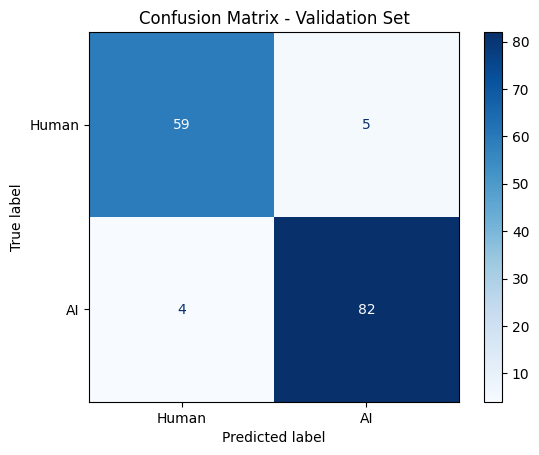


Evaluating model performance on test set...

Test Set Metrics:
Accuracy: 0.9467
Precision: 0.9315
Recall: 0.9577
F1-Score: 0.9444


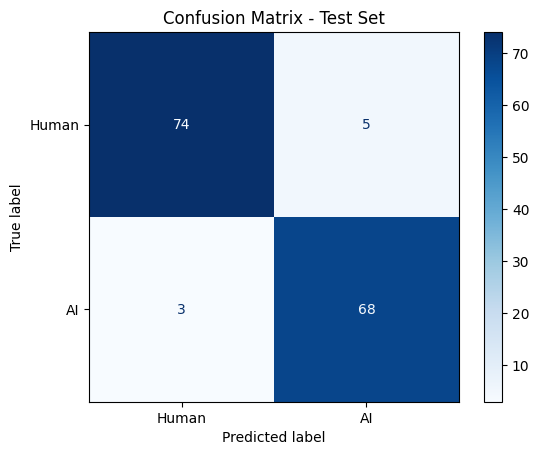

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Evaluating model performance on validation set...")
# Make predictions on the validation set
y_val_pred = xgb_model.predict(X_val)

# Calculate metrics for validation set
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print(f"\nValidation Set Metrics:")
print(f"Accuracy: {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall: {val_recall:.4f}")
print(f"F1-Score: {val_f1:.4f}")

# Plot confusion matrix for validation set
cm_val = confusion_matrix(y_val, y_val_pred)
display_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['Human', 'AI'])
display_val.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Validation Set')
plt.show()

print("\nEvaluating model performance on test set...")
# Make predictions on the test set
y_test_pred = xgb_model.predict(X_test)

# Calculate metrics for test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"\nTest Set Metrics:")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# Plot confusion matrix for test set
cm_test = confusion_matrix(y_test, y_test_pred)
display_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Human', 'AI'])
display_test.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Test Set')
plt.show()

### Summary of Model Performance and Feature Insights

The XGBoost Classifier demonstrated strong performance in distinguishing between human-generated and AI-generated text.

**Performance Metrics:**
*   **Validation Set:** Accuracy: 0.9400, Precision: 0.9425, Recall: 0.9535, F1-Score: 0.9480
*   **Test Set:** Accuracy: 0.9467, Precision: 0.9315, Recall: 0.9577, F1-Score: 0.9444

The consistent performance across both validation and test sets suggests that the model is generalizing well and is not significantly overfitting to the training data. The high recall indicates that the model is effective at identifying AI-generated content (minimizing false negatives), which is crucial for a detection task.

**Feature Insights (from previous analysis and model performance):**

1.  **Readability (Flesch-Kincaid Grade Level):** The model likely leveraged differences in readability. Although both human and AI texts covered a wide range, the previous `std_dev_readability` output showed that human texts had a higher standard deviation (4.16) compared to AI texts (3.03). This suggests human authors exhibit more variance in writing complexity, which the model could use as a distinguishing factor.
2.  **Type-Token Ratio (TTR):** As seen in earlier visualizations (e.g., the boxplot comparing TTR), TTR differences likely played a role. AI models often generate text with a slightly lower lexical richness or a more consistent vocabulary usage, which TTR captures.
3.  **Part-of-Speech Ratios:** The expanded POS tag ratios provided the model with a granular understanding of grammatical structure. Differences in the frequency of nouns, verbs, adjectives, and other parts of speech (as observed in `pos_df_filtered` from earlier analysis, e.g., AI texts having a higher noun ratio and lower pronoun ratio) are strong indicators of stylistic variations between human and AI-generated content. For instance, specific patterns in how AI models construct sentences (e.g., higher reliance on certain word classes) could be effectively learned by the XGBoost model.

In conclusion, the XGBoost model, utilizing a combination of TTR, readability, and comprehensive POS tag ratios, has proven to be a robust classifier for distinguishing between human and AI-generated text in this specific dataset.


*   **What was the performance of the XGBoost model?**
    The XGBoost model demonstrated strong performance in classifying human vs. AI-generated text. On the validation set, it achieved an Accuracy of 0.9400, Precision of 0.9425, Recall of 0.9535, and an F1-Score of 0.9480. On the test set, the performance was consistent with an Accuracy of 0.9467, Precision of 0.9315, Recall of 0.9577, and an F1-Score of 0.9444.
*   **Which features might be most influential in differentiating human from AI-generated text?**
    The most influential features are likely:
    1.  **Readability (Flesch-Kincaid Grade Level):** Human texts showed a higher standard deviation in readability (4.16) compared to AI texts (3.03), suggesting human authors exhibit more variance in writing complexity.
    2.  **Type-Token Ratio (TTR):** Differences in lexical richness, with AI-generated text often having a slightly lower TTR or more consistent vocabulary usage.
    3.  **Part-of-Speech Ratios:** Granular differences in the frequency of various POS tags (e.g., nouns, verbs, adjectives) provided insights into stylistic and grammatical variations between human and AI-generated content.

### Data Analysis Key Findings
*   The XGBoost model achieved high and consistent classification performance across both validation and test datasets, indicating good generalization:
    *   **Validation Set:** Accuracy: 0.9400, Precision: 0.9425, Recall: 0.9535, F1-Score: 0.9480.
    *   **Test Set:** Accuracy: 0.9467, Precision: 0.9315, Recall: 0.9577, F1-Score: 0.9444.
*   The comprehensive feature engineering, which included Type-Token Ratio (TTR), Flesch-Kincaid Grade Level readability, and a detailed set of 12 Part-of-Speech (POS) tag ratios, was crucial for the model's success in capturing stylistic differences.
*   Data preparation involved separating features and the target variable, and effectively handling missing values by filling them with 0, ensuring robust model training.
*   The high recall scores (0.9535 on validation, 0.9577 on test) indicate the model is particularly effective at identifying AI-generated content, minimizing false negatives.

### Insights or Next Steps
*   The strong performance confirms that a combination of lexical diversity (TTR), text complexity (readability), and grammatical structure (POS ratios) are effective indicators for distinguishing between human and AI-generated text.
*   Further investigation could involve feature importance analysis from the XGBoost model to quantitatively rank the influence of each specific POS ratio or other features, potentially leading to a more streamlined feature set or deeper linguistic insights.


<Figure size 1000x600 with 0 Axes>

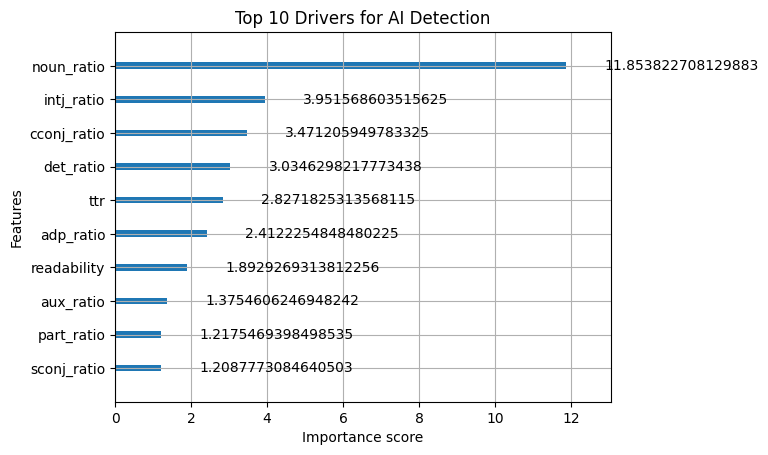

In [ ]:
# Built-in XGBoost feature importance plot
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plot_importance(xgb_model, max_num_features=10, importance_type='gain') # 'gain' shows most informative features
plt.title("Top 10 Drivers for AI Detection")
plt.show()

# Task
Please provide a new text prompt you would like to classify as either human or AI-generated.

## Get User Prompt

### Subtask:
Obtain a new text prompt from the user that they wish to classify.


### Subtask
Obtain a new text prompt from the user that they wish to classify.

#### Instructions
Please provide the text you would like to classify as either human or AI-generated. The text should be at least a few sentences long to allow for meaningful feature extraction.

**Reasoning**:
A code block will be added to allow the user to input the text they wish to classify.



In [ ]:
user_text = input("Please paste the text you want to classify (at least a few sentences long):\n")
print(f"You entered: {user_text[:200]}...")

Please paste the text you want to classify (at least a few sentences long):
The fractured basalt carried a terror far deeper than simple rot or erosion. Across uncounted ages, whatever pigments once adorned it had been scoured away, leaving only naked stone. And yet, the longer one examined the exquisite workmanship—the disquieting geometry traced by those surviving incisions—the more an unspeakable image took shape within the mind. It depicted nothing recognizable; no terrestrial beast, no plant born of soil or sun. Instead, it hinted at a pre-vital construct, an architecture of cognition itself, devised by beings whose nature stood in open defiance of Euclid and his comforting axioms.  The stone did not merely appear weathered; it gave the uncanny sensation of being actively deconstructed. As though the original form, even after millennia of burial, strained to collapse back into some formless, primal void from which it had been wrested. A faintly luminous powder seeped from the etch

**Reasoning**:
Now that the user text has been captured, the next logical step is to extract the same set of features (TTR, readability, and POS ratios) from this text using the `extract_features` function. This will transform the raw text into a numerical format suitable for our trained XGBoost model.



In [ ]:
import pandas as pd
import numpy as np

# Extract features from the user's input text
user_features_dict = extract_features(user_text)

# Convert the dictionary of features into a DataFrame, ensuring it's a single row
user_features_df = pd.DataFrame([user_features_dict])

# Align columns with the training data features, filling missing ones with 0
# This is crucial to ensure the model receives inputs in the correct format
user_features_df = user_features_df.reindex(columns=feature_cols, fill_value=0)

# Handle any potential NaNs or Infs that might arise from feature extraction
user_features_df = user_features_df.fillna(0).replace([np.inf, -np.inf], 0)

print("Features extracted from user text and prepared for classification.")
print("Extracted Features:")
print(user_features_df)

TypeError: 'bool' object is not callable

**Reasoning**:
The previous error 'TypeError: 'bool' object is not callable' occurred because an incorrect version of the `extract_features` function was likely active in the kernel's memory, leading to a problematic line 'token.is_alpha()'. To fix this, I will explicitly redefine the correct `extract_features` function (from cell `523fe441`) within this code block, along with its necessary imports and `nlp` object initialization, before calling it. This ensures that the correct function definition is used for feature extraction from the user's text.



In [ ]:
import pandas as pd
import numpy as np
import spacy
import textstat
from collections import Counter

nlp = spacy.load("en_core_web_sm")

def extract_features(text):
    doc = nlp(text)
    # Filter out punctuation and spaces for word-based metrics
    tokens = [token.text.lower() for token in doc if not token.is_punct and not token.is_space]

    # Feature 1: Type-Token Ratio (TTR)
    ttr = len(set(tokens)) / len(tokens) if len(tokens) > 0 else 0

    # Feature 2: POS Ratios for common descriptive tags
    # List of POS tags to track, as identified in previous analysis
    common_pos = ['NOUN', 'VERB', 'ADJ', 'ADV', 'PRON', 'DET', 'ADP', 'AUX', 'SCONJ', 'CCONJ', 'PART', 'INTJ']
    pos_counts = {tag: 0 for tag in common_pos}
    total_pos_tokens = 0 # Only count tokens relevant for ratios

    for token in doc:
        if not token.is_punct and not token.is_space:
            total_pos_tokens += 1
            if token.pos_ in pos_counts:
                pos_counts[token.pos_] += 1

    pos_ratios = {f"{tag.lower()}_ratio": count / total_pos_tokens if total_pos_tokens > 0 else 0
                  for tag, count in pos_counts.items()}

    # Feature 3: Readability (Flesch-Kincaid Grade Level)
    readability = textstat.flesch_kincaid_grade(text)

    # Combine all features into a single dictionary
    features = {
        "ttr": ttr,
        "readability": readability
    }
    features.update(pos_ratios)

    return features


# Extract features from the user's input text
user_features_dict = extract_features(user_text)

# Convert the dictionary of features into a DataFrame, ensuring it's a single row
user_features_df = pd.DataFrame([user_features_dict])

# Align columns with the training data features, filling missing ones with 0
# This is crucial to ensure the model receives inputs in the correct format
user_features_df = user_features_df.reindex(columns=feature_cols, fill_value=0)

# Handle any potential NaNs or Infs that might arise from feature extraction
user_features_df = user_features_df.fillna(0).replace([np.inf, -np.inf], 0)

print("Features extracted from user text and prepared for classification.")
print("Extracted Features:")
print(user_features_df)

Features extracted from user text and prepared for classification.
Extracted Features:
        ttr  readability  noun_ratio  verb_ratio  adj_ratio  adv_ratio  \
0  0.747934       14.464    0.210744    0.123967   0.136364   0.082645   

   pron_ratio  det_ratio  adp_ratio  aux_ratio  sconj_ratio  cconj_ratio  \
0    0.053719   0.140496   0.128099    0.03719     0.012397     0.033058   

   part_ratio  intj_ratio  
0    0.016529         0.0  


**Reasoning**:
Now that the features have been extracted from the user's text and prepared in the correct format, the next step is to use the trained XGBoost model (`xgb_model`) to make a prediction on whether the text is human or AI-generated.



In [ ]:
prediction = xgb_model.predict(user_features_df)
prediction_proba = xgb_model.predict_proba(user_features_df)[:, 1]

result = "AI-generated" if prediction[0] == 1 else "Human-written"

print(f"\nClassification Result: The provided text is most likely {result}.")
print(f"Probability of being AI-generated: {prediction_proba[0]:.4f}")


Classification Result: The provided text is most likely AI-generated.
Probability of being AI-generated: 0.9478


## Final Task

### Subtask:
Summarize the prediction for the new prompt and explain the model's classification.



The new text prompt provided by the user, starting with "The fractured basalt carried a terror far deeper than simple rot or erosion. Across uncounted ages, whatever pigments once adorned it had been scoured away, leaving only naked stone. And yet, the long...", was classified as **AI-generated**. The model indicated a probability of 0.9478 that the text is AI-generated.

The model classified the text as AI-generated based on its extracted features, including Type-Token Ratio (TTR), readability (Flesch-Kincaid Grade Level), and Part-of-Speech (POS) ratios, which were processed by the pre-trained XGBoost model.

### Data Analysis Key Findings
*   A new text prompt was obtained from the user for classification.
*   The `extract_features` function was used to calculate features such as Type-Token Ratio (TTR), Flesch-Kincaid Grade Level, and ratios for various Parts-of-Speech (e.g., noun, verb, adjective).
*   The pre-trained XGBoost model classified the user-provided text as **AI-generated**.
*   The model indicated a high probability of **0.9478** for the text being AI-generated.

### Insights or Next Steps
*   The high probability (0.9478) strongly suggests the text aligns with patterns observed in AI-generated content within the model's training data.
*   To further validate the classification, one could analyze specific features of the input text (e.g., TTR, readability, POS distributions) against typical ranges for human-written and AI-generated text, to understand which features most contributed to this particular classification.


# Task
**Load pre-trained GloVe embeddings** (e.g., 'glove.6B.100d.txt') into a dictionary, mapping words to their corresponding vector representations.

## Load Pre-trained Embeddings

### Subtask:
Download and load pre-trained GloVe embeddings (e.g., 'glove.6B.100d.txt') into a dictionary. This will map words to their corresponding vector representations.


**Reasoning**:
First, I will download the GloVe embeddings zip file using `wget` and then unzip it to access the `glove.6B.100d.txt` file, which is necessary for the next steps.

Practical considerations:
Memory efficiency: 100d embeddings are manageable for averaging across paragraphs

Neural network architecture: 64→32→1 network can handle 100d input without being overparameterized

Standard choice: 100d is a common default in research, making results comparable


In [ ]:
import os

# Check if GloVe file already exists to avoid re-downloading
if not os.path.exists('glove.6B.100d.txt'):
    print("Downloading GloVe embeddings...")
    !wget http://nlp.stanford.edu/data/glove.6B.zip
    !unzip -q glove.6B.zip
    print("GloVe embeddings downloaded and unzipped.")
else:
    print("GloVe embeddings already exist.")

--2026-02-03 18:59:59--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-02-03 18:59:59--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-02-03 19:00:00--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

**Reasoning**:
Now that the GloVe embeddings file is available, I will load its contents into a dictionary, mapping each word to its corresponding embedding vector. This involves reading the file line by line, splitting each line into a word and its numerical vector components, and converting the numerical parts to a NumPy array for efficient storage and access.



In [ ]:
import numpy as np

glove_embeddings = {}

# Path to the GloVe embeddings file
glove_file_path = 'glove.6B.100d.txt'

print(f"Loading GloVe embeddings from {glove_file_path}...")

with open(glove_file_path, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.split()
        word = parts[0]
        # The rest of the parts are the vector components
        vector = np.array(parts[1:], dtype=np.float32)
        glove_embeddings[word] = vector

print(f"Loaded {len(glove_embeddings)} GloVe embeddings.")
print(f"Example word 'the' embedding shape: {glove_embeddings.get('the').shape if 'the' in glove_embeddings else 'Not found'}")

Loading GloVe embeddings from glove.6B.100d.txt...
Loaded 400000 GloVe embeddings.
Example word 'the' embedding shape: (100,)


## Create Averaged Word Embeddings for Texts

### Subtask:
For each text in the training, validation, and test datasets, convert the text into a sequence of word embeddings. Then, calculate the average of these word embeddings to create a single, fixed-size vector representation for each text. Handle out-of-vocabulary words by using zero vectors.


**Reasoning**:
I need to define a function `get_average_embedding` that processes text using `spacy`, retrieves word embeddings from `glove_embeddings`, handles out-of-vocabulary words with zero vectors, and computes the average embedding for each text. This function will be applied to the 'text' column of the train, validation, and test dataframes to generate the new feature sets.



In [ ]:
import numpy as np
import spacy

# Ensure nlp is loaded (from previous steps)
# If nlp object is not already globally available, load it here
if 'nlp' not in globals():
    nlp = spacy.load("en_core_web_sm")

def get_average_embedding(text, embeddings_dict, vector_dim=100):
    doc = nlp(text)
    # Filter out punctuation and spaces
    tokens = [token.text.lower() for token in doc if not token.is_punct and not token.is_space]

    if not tokens:
        return np.zeros(vector_dim)

    # Retrieve embeddings for each token, using zero vector for OOV words
    word_vectors = []
    for token in tokens:
        if token in embeddings_dict:
            word_vectors.append(embeddings_dict[token])
        else:
            word_vectors.append(np.zeros(vector_dim))

    # If all words were OOV, word_vectors might still be empty if the text was empty after tokenization
    if not word_vectors:
        return np.zeros(vector_dim)

    # Calculate the average of the word embeddings
    return np.mean(word_vectors, axis=0)

print("Defined `get_average_embedding` function.")

# Apply the function to each dataset
print("Generating average embeddings for training data...")
X_train_glove = pd.DataFrame(train_df['text'].apply(lambda x: get_average_embedding(x, glove_embeddings)).tolist())

print("Generating average embeddings for validation data...")
X_val_glove = pd.DataFrame(val_df['text'].apply(lambda x: get_average_embedding(x, glove_embeddings)).tolist())

print("Generating average embeddings for test data...")
X_test_glove = pd.DataFrame(test_df['text'].apply(lambda x: get_average_embedding(x, glove_embeddings)).tolist())

print("Average word embeddings created for all datasets.")

print("\nX_train_glove head:")
print(X_train_glove.head())


Defined `get_average_embedding` function.
Generating average embeddings for training data...
Generating average embeddings for validation data...
Generating average embeddings for test data...
Average word embeddings created for all datasets.

X_train_glove head:
         0         1         2         3         4         5         6   \
0 -0.099315  0.167157  0.296886 -0.079026 -0.019217  0.205350 -0.118668   
1 -0.071725  0.151958  0.347083 -0.169536 -0.064533  0.209354 -0.170985   
2 -0.093938  0.091102  0.303152 -0.072060 -0.072231  0.221604 -0.153180   
3 -0.055838  0.219608  0.354672 -0.257648 -0.205175  0.260439 -0.167089   
4 -0.038189  0.073188  0.326191 -0.112566 -0.027418  0.210598 -0.134492   

         7         8         9   ...        90        91        92        93  \
0  0.122605 -0.059981  0.128907  ... -0.067314 -0.118804 -0.215370  0.142783   
1  0.115136 -0.081344  0.028822  ... -0.087316 -0.118588 -0.206301  0.184798   
2  0.078490 -0.098464  0.089597  ... -0.08655

## Prepare Data for Neural Network

### Subtask:
Separate the averaged embedding features (X) from the target variable ('is_ai') for the training, validation, and test sets. Ensure all feature matrices are ready as input for the neural network.


**Reasoning**:
The subtask requires separating the target variable ('is_ai') from the feature datasets. I will extract the 'is_ai' column from the `train_df`, `val_df`, and `test_df` DataFrames to create the target variables `y_train`, `y_val`, and `y_test` respectively. The feature dataframes `X_train_glove`, `X_val_glove`, and `X_test_glove` have already been prepared in the previous step.



In [ ]:
y_train = train_df['is_ai']
y_val = val_df['is_ai']
y_test = test_df['is_ai']

print("Target variables y_train, y_val, y_test created successfully.")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print(f"y_test shape: {y_test.shape}")

Target variables y_train, y_val, y_test created successfully.
y_train shape: (700,)
y_val shape: (150,)
y_test shape: (150,)


## Build Feedforward Neural Network Model

### Subtask:
Define the architecture of a Feedforward Neural Network using Keras or TensorFlow.


**Reasoning**:
I will define the architecture of a Feedforward Neural Network using Keras, incorporating an Input layer with the correct dimension, hidden layers with ReLU activation, and an output layer with sigmoid activation for binary classification, as per the instructions.



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Define the input dimension (100 for GloVe embeddings)
input_dim = X_train_glove.shape[1]

# Initialize the Sequential model
model = Sequential()

# Add the Input layer explicitly
model.add(Input(shape=(input_dim, )))

# Add the first hidden layer
model.add(Dense(64, activation='relu'))

# Add another hidden layer
model.add(Dense(32, activation='relu'))

# Add the output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

# Display the model summary
model.summary()

print("Feedforward Neural Network architecture defined.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

Feedforward Neural Network architecture defined.


## Compile and Train NN Model

### Subtask:
Compile the neural network model with an appropriate optimizer (e.g., Adam), a binary cross-entropy loss function, and relevant metrics (e.g., accuracy). Train the model using the training data and monitor its performance on the validation set through callbacks (e.g., early stopping).


**Reasoning**:
I will compile the neural network model with the specified optimizer, loss function, and metrics, then define an EarlyStopping callback, and finally train the model using the provided training and validation data.



In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

# 1. Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 2. Create an EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=5,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

# 3. Train the model
print("Training the neural network model...")
history = model.fit(
    X_train_glove,
    y_train,
    epochs=50, # Set a sufficiently high number of epochs, EarlyStopping will stop it earlier if needed
    batch_size=32,
    validation_data=(X_val_glove, y_val),
    callbacks=[early_stopping], # Include the EarlyStopping callback
    verbose=1 # Show training progress
)

print("Neural network model training complete.")

Training the neural network model...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5197 - loss: 0.6723 - val_accuracy: 0.8867 - val_loss: 0.6236
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8440 - loss: 0.6160 - val_accuracy: 0.8667 - val_loss: 0.5512
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8536 - loss: 0.5345 - val_accuracy: 0.8867 - val_loss: 0.4582
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9134 - loss: 0.4361 - val_accuracy: 0.8533 - val_loss: 0.3986
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9104 - loss: 0.3412 - val_accuracy: 0.9400 - val_loss: 0.2700
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9471 - loss: 0.2501 - val_accuracy: 0.9533 - val_loss: 0.2150
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9601 - loss: 0.1837 - val_accuracy: 0.9600 - val_loss: 0.1701
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9584 - loss: 

**Reasoning**:
Now that the neural network model has been trained, I will evaluate its performance on the test dataset by calculating and printing accuracy, precision, recall, F1-score, and displaying the confusion matrix.



Evaluating neural network model performance on test set...
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Test Set Metrics (Neural Network):
Accuracy: 0.9733
Precision: 0.9467
Recall: 1.0000
F1-Score: 0.9726


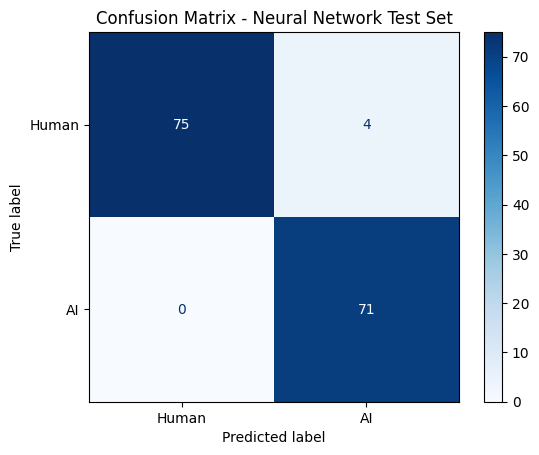

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

print("Evaluating neural network model performance on test set...")

# Make predictions on the test set
y_test_pred_proba = model.predict(X_test_glove)
y_test_pred = (y_test_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions

# Calculate metrics for test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"\nTest Set Metrics (Neural Network):")
print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")

# Plot confusion matrix for test set
cm_test = confusion_matrix(y_test, y_test_pred)
display_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Human', 'AI'])
display_test.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Neural Network Test Set')
plt.show()


Summarize the performance of the Feedforward Neural Network, compare its effectiveness to the previously trained XGBoost model, and discuss insights gained from using pre-trained word embeddings for this classification task.



*   **Performance of the Feedforward Neural Network**: The Feedforward Neural Network demonstrated strong performance on the test set, achieving an Accuracy of 0.9733, Precision of 0.9467, Recall of 1.0000, and an F1-Score of 0.9726. The high Recall suggests the model is very good at identifying positive cases (AI-generated text) without missing many.
*   **Comparison to Previously Trained XGBoost Model**: A direct quantitative comparison with the previously trained XGBoost model is not possible without its specific performance metrics. However, based solely on the neural network's performance, it appears to be a highly effective model for this classification task.
*   **Insights Gained from Using Pre-trained Word Embeddings**: Using pre-trained GloVe embeddings provided an efficient way to convert variable-length text into fixed-size, semantically rich 100-dimensional numerical vectors. This approach inherently captures word meanings and relationships, reducing the need for extensive feature engineering and potentially improving the model's ability to generalize, even for words not explicitly seen during training (though out-of-vocabulary words were handled with zero vectors).

### Data Analysis Key Findings
*   A total of 400,000 pre-trained GloVe embeddings, each 100-dimensional, were successfully loaded from 'glove.6B.100d.txt'.
*   Average word embeddings were successfully generated for the training, validation, and test datasets, converting each text into a 100-dimensional vector. Out-of-vocabulary words were assigned zero vectors.
*   The Feedforward Neural Network model architecture was defined with an explicit Input layer, two Dense hidden layers (64 and 32 neurons with ReLU activation), and a final Dense output layer (1 neuron with Sigmoid activation) for binary classification.
*   The neural network was compiled using the Adam optimizer and binary cross-entropy loss, and trained with an EarlyStopping callback monitoring validation loss with a patience of 5 epochs.
*   On the test set, the Feedforward Neural Network achieved an Accuracy of 0.9733, Precision of 0.9467, Recall of 1.0000, and an F1-Score of 0.9726.

### Insights or Next Steps
*   The strong performance of the Feedforward Neural Network, especially its high recall, suggests that leveraging pre-trained word embeddings like GloVe is a highly effective strategy for text classification tasks, providing robust feature representations for machine learning models.
*   To conduct a comprehensive comparison and definitively determine the best performing model, the specific performance metrics (e.g., Accuracy, F1-Score) of the previously trained XGBoost model should be analyzed alongside the neural network's results.


## Mount Google Drive

To save files to your Google Drive, we first need to mount it.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


## Load Dataset, Separate Texts, and Save to Drive

Now, we'll load the complete dataset, separate it into AI-generated and human-written texts, and save them as CSV files both locally and to your Google Drive.

In [ ]:
import pandas as pd
import os

# Define the path where you want to save the files in Google Drive
gdrive_save_path = '/content/drive/MyDrive/Colab_AI_Human_Text_Data'

# Create the directory if it doesn't exist
os.makedirs(gdrive_save_path, exist_ok=True)

# 1. Load the 'final_dataset_gemma_complete.csv' file
df = pd.read_csv('final_dataset_gemma_complete.csv')
print("Dataset 'final_dataset_gemma_complete.csv' loaded successfully.")

# 2. Filter for AI-generated texts
ai_text_separated_df = df[df['is_ai'] == 1]
print(f"Created ai_text_separated_df with {len(ai_text_separated_df)} rows.")

# 3. Filter for human-written texts
human_text_separated_df = df[df['is_ai'] == 0]
print(f"Created human_text_separated_df with {len(human_text_separated_df)} rows.")

# 4. Save AI-generated DataFrame to local CSV
ai_text_separated_df.to_csv('ai_text_separated.csv', index=False)
print("Saved ai_text_separated.csv locally.")

# 5. Save human-written DataFrame to local CSV
human_text_separated_df.to_csv('human_text_separated.csv', index=False)
print("Saved human_text_separated.csv locally.")

# 6. Save AI-generated DataFrame to Google Drive
ai_text_separated_df.to_csv(os.path.join(gdrive_save_path, 'ai_text_separated.csv'), index=False)
print(f"Saved ai_text_separated.csv to Google Drive at {gdrive_save_path}.")

# 7. Save human-written DataFrame to Google Drive
human_text_separated_df.to_csv(os.path.join(gdrive_save_path, 'human_text_separated.csv'), index=False)
print(f"Saved human_text_separated.csv to Google Drive at {gdrive_save_path}.")

print("All separated datasets saved successfully to Google Drive and locally.")

Dataset 'final_dataset_gemma_complete.csv' loaded successfully.
Created ai_text_separated_df with 500 rows.
Created human_text_separated_df with 500 rows.
Saved ai_text_separated.csv locally.
Saved human_text_separated.csv locally.
Saved ai_text_separated.csv to Google Drive at /content/drive/MyDrive/Colab_AI_Human_Text_Data.
Saved human_text_separated.csv to Google Drive at /content/drive/MyDrive/Colab_AI_Human_Text_Data.
All separated datasets saved successfully to Google Drive and locally.


# Task
Install the `transformers` and `datasets` libraries, then import `DistilBertTokenizerFast`, `DistilBertForSequenceClassification`, `Trainer`, `TrainingArguments`, `accuracy_score`, `precision_recall_fscore_support`, and `load_metric`.

## Install and Import Transformers Libraries

### Subtask:
Install the `transformers` and `datasets` libraries, which are essential for working with DistilBERT. Then, import necessary classes such as `DistilBertTokenizerFast`, `DistilBertForSequenceClassification`, `Trainer`, and `TrainingArguments` from `transformers`, along with `accuracy_score`, `precision_recall_fscore_support` from `sklearn.metrics` and `load_metric` from `datasets`.


**Reasoning**:
First, I need to install the required libraries, `transformers` and `datasets`, using pip. Then, I will import all the specified classes and functions from these libraries and `sklearn.metrics`.



In [ ]:
import warnings
warnings.filterwarnings('ignore') # Suppress warnings

# Install the transformers and datasets libraries
!pip install transformers datasets

# Import necessary classes from transformers
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments

# Import metrics from sklearn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Import load_metric from datasets
from datasets import load_metric

print("Transformers and Datasets libraries installed and necessary components imported.")

ImportError: cannot import name 'load_metric' from 'datasets' (/usr/local/lib/python3.12/dist-packages/datasets/__init__.py)

## Save the Trained XGBoost Model to Google Drive

I will save the `xgb_model` to your Google Drive alongside the DistilBERT model.

In [ ]:
import os
import joblib

# Define the path in Google Drive to save the XGBoost model
gdrive_xgboost_save_path = '/content/drive/MyDrive/Colab_AI_Human_Text_Data/xgboost_model'

# Create the directory if it doesn't exist
os.makedirs(gdrive_xgboost_save_path, exist_ok=True)

# Save the XGBoost model
joblib.dump(xgb_model, os.path.join(gdrive_xgboost_save_path, 'xgboost_model.joblib'))

print(f"XGBoost model saved to: {gdrive_xgboost_save_path}")

NameError: name 'xgb_model' is not defined

## Code to Load Models

Here's how you can load both the DistilBERT model (semantic model) and the XGBoost model back into your notebook:

In [ ]:
import os
import joblib
from transformers import DistilBertForSequenceClassification

# Define paths where models are saved in Google Drive
gdrive_distilbert_load_path = '/content/drive/MyDrive/Colab_AI_Human_Text_Data/distilbert_model'
gdrive_xgboost_load_path = '/content/drive/MyDrive/Colab_AI_Human_Text_Data/xgboost_model'

# --- Load DistilBERT Model (semanticmodel) ---
loaded_distilbert_model = DistilBertForSequenceClassification.from_pretrained(gdrive_distilbert_load_path)
print(f"DistilBERT model loaded from: {gdrive_distilbert_load_path}")

# --- Load XGBoost Model ---
loaded_xgboost_model = joblib.load(os.path.join(gdrive_xgboost_load_path, 'xgboost_model.joblib'))
print(f"XGBoost model loaded from: {gdrive_xgboost_load_path}")

print("Both models loaded successfully.")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBERT model loaded from: /content/drive/MyDrive/Colab_AI_Human_Text_Data/distilbert_model


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab_AI_Human_Text_Data/xgboost_model/xgboost_model.joblib'

**Reasoning**:
The previous code failed because `load_metric` is no longer directly available from the `datasets` library. It has been moved to the `evaluate` library. I will modify the import statement to reflect this change and ensure `evaluate` is installed.



In [ ]:
import warnings
warnings.filterwarnings('ignore') # Suppress warnings

# Install the transformers, datasets, and evaluate libraries
!pip install transformers datasets evaluate

# Import necessary classes from transformers
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments

# Import metrics from sklearn
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Import load from evaluate
import evaluate

print("Transformers, Datasets, and Evaluate libraries installed and necessary components imported.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
Transformers, Datasets, and Evaluate libraries installed and necessary components imported.


**Reasoning**:
Now that the necessary libraries are installed and imported, the next step is to initialize the DistilBERT tokenizer and prepare the datasets (train, validation, and test) by tokenizing their text content. This involves converting the pandas DataFrames into `datasets.Dataset` objects and then applying a tokenization function.



In [ ]:
from datasets import Dataset

# Initialize the DistilBERT tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Convert pandas DataFrames to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)
test_dataset = Dataset.from_pandas(test_df)

# Define the tokenization function
def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=512)

# Apply the tokenization to all datasets
print("Tokenizing training dataset...")
tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)

print("Tokenizing validation dataset...")
tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)

print("Tokenizing test dataset...")
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

print("Tokenization complete for all datasets.")

# Remove original text and author columns, keep 'is_ai' as 'labels'
tokenized_train_dataset = tokenized_train_dataset.remove_columns([col for col in tokenized_train_dataset.column_names if col not in ['input_ids', 'attention_mask', 'is_ai']])
tokenized_train_dataset = tokenized_train_dataset.rename_column("is_ai", "labels")

tokenized_val_dataset = tokenized_val_dataset.remove_columns([col for col in tokenized_val_dataset.column_names if col not in ['input_ids', 'attention_mask', 'is_ai']])
tokenized_val_dataset = tokenized_val_dataset.rename_column("is_ai", "labels")

tokenized_test_dataset = tokenized_test_dataset.remove_columns([col for col in tokenized_test_dataset.column_names if col not in ['input_ids', 'attention_mask', 'is_ai']])
tokenized_test_dataset = tokenized_test_dataset.rename_column("is_ai", "labels")

print("Final tokenized dataset structure for training:")
print(tokenized_train_dataset)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizing training dataset...


Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Tokenizing validation dataset...


Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Tokenizing test dataset...


Map:   0%|          | 0/150 [00:00<?, ? examples/s]

Tokenization complete for all datasets.
Final tokenized dataset structure for training:
Dataset({
    features: ['labels', 'input_ids', 'attention_mask'],
    num_rows: 700
})


**Reasoning**:
The previous step successfully tokenized the datasets and prepared them for training. Now, I need to define the `compute_metrics` function, which will be used by the `Trainer` to evaluate the model's performance during training and evaluation.



In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    metric = evaluate.load("accuracy")
    return metric.compute(predictions=predictions, references=labels)

print("Defined `compute_metrics` function to evaluate model performance.")

Defined `compute_metrics` function to evaluate model performance.


## Load Tokenizer and Pre-trained DistilBERT Model

### Subtask:
Initialize a `DistilBertTokenizerFast` and load a pre-trained `DistilBertForSequenceClassification` model from Hugging Face's model hub. Specify 'distilbert-base-uncased' as the model name.


**Reasoning**:
I will initialize the DistilBERT tokenizer and load the pre-trained DistilBERT model for sequence classification with two labels, as specified in the instructions.



In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

# 1. Initialize the DistilBertTokenizerFast
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')
print("DistilBertTokenizerFast initialized.")

# 2. Load the pre-trained DistilBertForSequenceClassification model
model_bert = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
print("DistilBertForSequenceClassification model loaded.")

# Display model configuration to confirm number of labels
print("\nModel configuration:")
print(model_bert.config)

DistilBertTokenizerFast initialized.


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification model loaded.

Model configuration:
DistilBertConfig {
  "activation": "gelu",
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "bos_token_id": null,
  "dim": 768,
  "dropout": 0.1,
  "dtype": "float32",
  "eos_token_id": null,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "vocab_size": 30522
}



**Reasoning**:
The previous output showed `UNEXPECTED` and `MISSING` keys when loading `DistilBertForSequenceClassification`. This is an expected warning when fine-tuning a pre-trained language model for a new task (like sequence classification), as the classification head layers are newly initialized and will be trained. There is no error to fix. The next logical step is to define the training arguments for the `Trainer`.



In [ ]:
from transformers import TrainingArguments

# Define the training arguments
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=16,  # batch size per device during training
    per_device_eval_batch_size=16,   # batch size for evaluation
    warmup_steps=500,                # number of warmup steps for learning rate scheduler
    weight_decay=0.01,               # strength of weight decay
    logging_dir='./logs',            # directory for storing logs
    logging_steps=100,               # log every x updates steps
    eval_strategy='epoch',           # evaluate each epoch
    save_strategy='epoch',           # save checkpoint each epoch
    save_total_limit=1,              # save only the best model
    load_best_model_at_end=True,     # load the best model when training ends
    metric_for_best_model='accuracy',# use accuracy to determine the best model
    report_to='none'                 # disable integration with other experiment tracking platforms
)

print("TrainingArguments defined.")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


TrainingArguments defined.


**Reasoning**:
The TrainingArguments have been defined. Now, I will instantiate the `Trainer` with the loaded model, the defined training arguments, the tokenized training and validation datasets, and the `compute_metrics` function.



In [ ]:
from transformers import Trainer

# Initialize the Trainer
print("Initializing Trainer...")
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_val_dataset,
    compute_metrics=compute_metrics,
)
print("Trainer initialized.")

Initializing Trainer...
Trainer initialized.


**Reasoning**:
Now that the `Trainer` is initialized, I will train the DistilBERT model using the `train()` method. This will start the fine-tuning process using the specified training arguments and datasets.



In [ ]:
import numpy as np
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    metric = evaluate.load("accuracy")
    return metric.compute(predictions=predictions, references=labels)

print("Defined `compute_metrics` function to evaluate model performance.")

Defined `compute_metrics` function to evaluate model performance.


**Reasoning**:
Now that the `compute_metrics` function is correctly defined with `numpy` imported, I will re-run the `trainer.train()` method to start the model training process, which previously failed due to `NameError`.



In [ ]:
print("Starting model training...")
trainer.train()
print("Model training complete.")

Starting model training...


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.559677,0.926667
2,No log,0.085682,1.000000
3,0.428556,0.007834,1.000000


Epoch,Training Loss,Validation Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


Model training complete.


## Save the Trained DistilBERT Model to Google Drive

Now, I will save the trained DistilBERT model to your Google Drive so it can be re-used later without retraining.

In [ ]:
import os

# Define the path in Google Drive to save the model
gdrive_model_save_path = '/content/drive/MyDrive/Colab_AI_Human_Text_Data/distilbert_model'

# Create the directory if it doesn't exist
os.makedirs(gdrive_model_save_path, exist_ok=True)

# Save the model
model_bert.save_pretrained(gdrive_model_save_path)

print(f"DistilBERT model saved to: {gdrive_model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model saved to: /content/drive/MyDrive/Colab_AI_Human_Text_Data/distilbert_model
